# REACTO — reading the surrogate after the campaign

The optimisation campaign ends with more than its best experiment: it ends with
a fitted Gaussian process, a model of the yield over the *whole* reaction space,
trained on every experiment performed. This notebook is what was extracted from
that model once the campaign was closed — where the yield is predicted to be
high, how far that region extends, which parameters it responds to, and which
confirmatory experiments follow from it.

The distinction with the campaign itself matters and is worth stating plainly in
a methods section. During the campaign, conditions were chosen by an acquisition
function that deliberately balances predicted yield against uncertainty: an
experiment is worth running partly *because* its outcome is unknown. Here the
logic is inverted. The campaign is over, the question is no longer what to learn
but what to trust, and every selection below takes the **best predicted yield**
subject to the surrogate being **confident** there.

## Decisions

These are choices, not consequences of the data, and they are applied uniformly.

1. **Within each region of interest, take the highest predicted yield** — the
   arg-max of the posterior mean μ. This is exploitation, by design.
2. **Require σ < 15 % everywhere.** A region where the surrogate is less certain
   than that returns *no* point. That is not a failure of the procedure: it is
   the finding that the campaign never went there, and it is reported as such.
3. **A predicted yield above 70 %** defines the favourable region.
4. **No ratio constraint** between `BuOH` and `[DMIPP]`; the only constraint is
   the one the campaign itself carried, `[DMIPP]` ≤ `BuOH`.
5. The search is over the **discrete grid** the campaign actually used, not over
   the continuous ranges enclosing it.

Thresholds 1–3 are reported with the plan they produce, so that a reader can see
what moving them would change.

## 0. Setup

Python 3.11, `bofire==0.3.1`, `botorch==0.17.0`, `gpytorch==1.15.2`,
`torch==2.10.0`, `scikit-learn==1.8.0`, `matplotlib`.

In [1]:
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import bofire.strategies.api as strategies
from bofire.data_models.api import Domain, Inputs, Outputs, Constraints
from bofire.data_models.features.api import DiscreteInput, ContinuousOutput
from bofire.data_models.objectives.api import MaximizeObjective
from bofire.data_models.constraints.api import LinearInequalityConstraint
from bofire.data_models.acquisition_functions.api import qLogNEI
from bofire.data_models.strategies.api import SoboStrategy

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

YIELD_THRESHOLD = 70.0    # a predicted yield above this is "favourable"
SIGMA_MAX       = 15.0    # posterior sd above this is "not to be trusted"
PREDICT_BATCH   = 8000    # rows per call to the surrogate, to bound memory

## 1. The model left by the campaign

The surrogate analysed here is the campaign's own, refitted on the same 19
experiments: the reaction space is redeclared exactly as it was optimised over,
and the strategy is told everything that was measured. No separate model is
built, and nothing below depends on a choice made in this notebook rather than
during the campaign.

In [2]:
def grid(lower, upper, step):
    return [round(float(v), 6) for v in np.arange(lower, upper + step / 2, step)]


domain = Domain(
    inputs=Inputs(features=[
        # [DMIPP] and BuOH are both concentrations in mol/L; the constraint
        # below compares them directly. BuOH is written [BuOH] outside the code.
        DiscreteInput(key="[DMIPP]",      values=grid(1.0, 6.7, 0.2),  unit="M"),
        DiscreteInput(key="BuOH",         values=grid(1.0, 10.8, 0.2), unit="M"),
        DiscreteInput(key="Cat. Loading", values=[5.0, 7.5, 10.0]),
        DiscreteInput(key="Temperature",  values=grid(25.0, 75.0, 5.0)),
        DiscreteInput(key="Res. Time",    values=[0.5, 1.0, 1.5, 2.0, 2.5]),
    ]),
    outputs=Outputs(features=[
        ContinuousOutput(key="Yield", objective=MaximizeObjective(w=1.0, bounds=(0.0, 100.0))),
    ]),
    constraints=Constraints(constraints=[
        LinearInequalityConstraint(features=["[DMIPP]", "BuOH"],
                                   coefficients=[1.0, -1.0], rhs=0.0),
    ]),
)

PARAMETERS = [f.key for f in domain.inputs.features]
OBJECTIVE  = domain.outputs.features[0].key
LEVELS     = {f.key: np.array(f.values, dtype=float) for f in domain.inputs.features}

EXPERIMENTS = pd.DataFrame([
    # [DMIPP], BuOH, Cat. Loading, Temperature, Res. Time, Yield
    (2.2,  6.0,  5.0, 50.0, 1.0, 16.0), (5.0,  8.6,  7.5, 60.0, 2.0, 50.0),
    (3.4,  7.0,  5.0, 35.0, 2.0, 16.0), (5.2,  8.4,  7.5, 40.0, 1.0, 19.0),
    (5.0,  8.4,  5.0, 50.0, 1.0, 15.0), (3.0,  7.4, 10.0, 65.0, 1.0, 69.0),
    (3.4,  7.0,  5.0, 65.0, 2.0, 30.0), (2.2,  6.0,  7.5, 60.0, 2.0, 61.0),
    (3.2,  7.4, 10.0, 35.0, 2.0, 36.0), (2.2,  5.8,  7.5, 35.0, 1.0, 16.0),
    (1.8,  6.0, 10.0, 60.0, 2.0, 72.0), (1.0,  3.8, 10.0, 70.0, 2.0, 85.0),
    (1.0,  1.0, 10.0, 75.0, 2.5, 58.0), (1.0,  5.0, 10.0, 75.0, 1.5, 77.0),
    (5.0,  5.0, 10.0, 70.0, 2.5, 55.0), (1.0,  1.0, 10.0, 70.0, 2.0, 73.0),
    (1.0,  7.6, 10.0, 70.0, 1.5, 53.0), (1.6,  3.4, 10.0, 65.0, 1.5, 88.0),
    (2.6,  3.2, 10.0, 70.0, 1.0, 68.0),
], columns=PARAMETERS + [OBJECTIVE])

strategy = strategies.map(SoboStrategy(domain=domain, acquisition_function=qLogNEI()))
strategy.tell(experiments=EXPERIMENTS)

best_experiment = EXPERIMENTS.loc[EXPERIMENTS[OBJECTIVE].idxmax()]
print(f"surrogate fitted on {len(EXPERIMENTS)} experiments; "
      f"best measured yield {best_experiment[OBJECTIVE]:.0f} %")

surrogate fitted on 19 experiments; best measured yield 88 %


### What the fitted surrogate actually is

Worth reporting exactly, because it is the object every number below comes from:
a single-task Gaussian process with a **squared-exponential (RBF) kernel under
automatic relevance determination** — one length scale per parameter — a
constant mean, and a fitted noise term. Inputs are scaled to the unit cube and
the yield is standardised before fitting, so the length scales are directly
comparable to one another. Hyperparameters are obtained by maximising the
marginal likelihood under log-normal priors, which is what keeps them
identifiable at all from 19 points in five dimensions.

The fitted noise level is the surrogate's estimate of the experimental
reproducibility it would need to assume to explain the data it was given. It is
inferred, not measured, and it sets the floor of the posterior uncertainty
everywhere.

In [3]:
def describe_surrogate(strategy):
    surrogate = strategy.surrogates.surrogates[0]
    model     = surrogate.model
    keys      = surrogate.inputs.get_keys()          # the model's own input order
    lengthscales = model.covar_module.lengthscale.detach().cpu().numpy().ravel()
    noise_sd = float(np.sqrt(model.likelihood.noise.detach().cpu().numpy().ravel()[0]))
    print(f"kernel            : {type(model.covar_module).__name__}, ARD over {len(keys)} inputs")
    print(f"mean              : {type(model.mean_module).__name__}")
    print(f"input transform   : {type(model.input_transform).__name__} (unit cube)")
    print(f"outcome transform : {type(model.outcome_transform).__name__}")
    print(f"noise sd          : {noise_sd:.3f} (standardised yield) "
          f"= {noise_sd * EXPERIMENTS[OBJECTIVE].std():.1f} % of yield")
    return pd.Series(dict(zip(keys, lengthscales)), name="length scale").loc[PARAMETERS]


length_scales = describe_surrogate(strategy)
length_scales.round(3).to_frame()

kernel            : RBFKernel, ARD over 5 inputs
mean              : ConstantMean
input transform   : Normalize (unit cube)
outcome transform : Standardize
noise sd          : 0.074 (standardised yield) = 1.9 % of yield


,length scale
[DMIPP],0.862
BuOH,0.527
Cat. Loading,0.884
Temperature,0.642
Res. Time,0.833


## 2. Predicting over the whole reaction space

The grid is enumerated, the conditions violating `[DMIPP]` ≤ `BuOH` are
discarded, and the surrogate is evaluated at every survivor. The result is a
posterior mean μ and a posterior standard deviation σ attached to every set of
conditions the campaign could have run — roughly 1.7 × 10⁵ of them, against the
19 that were actually performed.

This is the step that turns an optimiser into a map. It costs one Gaussian
process evaluation per grid point and no experiments at all.

In [4]:
def feasible_grid(domain):
    # Every combination of levels satisfying the domain's linear constraints.
    keys = [f.key for f in domain.inputs.features]
    full = pd.DataFrame(list(product(*[LEVELS[k] for k in keys])), columns=keys)
    mask = pd.Series(True, index=full.index)
    for con in domain.constraints.constraints:
        lhs = sum(a * full[k] for k, a in zip(con.features, con.coefficients))
        mask &= lhs <= float(con.rhs) + 1e-6
    return full[mask].reset_index(drop=True), len(full)


def predict(strategy, points, batch=PREDICT_BATCH):
    # Posterior mean and sd, in batches to bound memory.
    mu, sd = [], []
    for start in range(0, len(points), batch):
        chunk = strategy.predict(points.iloc[start:start + batch][PARAMETERS])
        mu.append(chunk[f"{OBJECTIVE}_pred"].to_numpy())
        sd.append(chunk[f"{OBJECTIVE}_sd"].to_numpy())
    return np.concatenate(mu), np.concatenate(sd)


MAP, n_total = feasible_grid(domain)
MAP["mu"], MAP["sd"] = predict(strategy, MAP)
print(f"{len(MAP):,} feasible conditions out of {n_total:,} "
      f"({len(MAP)/n_total:.0%} survive [DMIPP] <= BuOH)")
MAP[["mu", "sd"]].describe().round(1).T

172,260 feasible conditions out of 239,250 (72% survive [DMIPP] <= BuOH)


,count,mean,std,min,25%,50%,75%,max
mu,172260.0,34.3,17.9,-3.0,21.3,31.5,46.8,87.8
sd,172260.0,12.7,3.9,2.5,9.9,12.8,15.6,24.3


## 3. The predicted optimum

The best point of the map, compared with the best experiment actually performed.
Two things are being asked of this comparison: whether the surrogate believes
the campaign stopped short, and whether it believes it with any confidence. The
answer here is that it does not — the predicted optimum falls one grid step from
the best experiment, at the same yield and with a narrow posterior. The campaign
converged, and the map's value lies elsewhere: in what it says about the
*extent* of that optimum and about the regions the optimiser abandoned.

In [5]:
optimum = MAP.loc[MAP.mu.idxmax()]
comparison = pd.DataFrame({
    "predicted optimum": {**{k: optimum[k] for k in PARAMETERS},
                          "yield": f"{optimum.mu:.0f} % +/- {optimum.sd:.0f}"},
    "best experiment":   {**{k: best_experiment[k] for k in PARAMETERS},
                          "yield": f"{best_experiment[OBJECTIVE]:.0f} % (measured)"},
})
comparison

,predicted optimum,best experiment
[DMIPP],1.2,1.6
BuOH,3.4,3.4
Cat. Loading,10.0,10.0
Temperature,65.0,65.0
Res. Time,1.5,1.5
yield,88 % +/- 3,88 % (measured)


## 4. What the yield responds to

Two readings, which answer different questions and disagree in an informative
way.

**Length scales** say how fast the surrogate believes the yield varies along
each parameter, in units of that parameter's full range. A short length scale
means the response turns over quickly; a long one means it is smooth. This is a
statement about the *shape* of the response, not about how much the parameter
matters: a long, steady slope has a long length scale and a large effect.

**A sweep of the surrogate** answers the second question directly. Each
parameter is walked across its levels with the others held at the predicted
optimum, and the spread of the predicted yield is recorded. Because a single
background can flatter or flatten an effect, the sweep is repeated over 200
feasible backgrounds drawn at random and the median spread reported alongside.
Only combinations satisfying `[DMIPP]` ≤ `BuOH` are swept.

Where the two columns disagree the effect is local rather than absent: a
parameter can dominate near the optimum and matter little in the rest of the
space, which is a statement about interactions, not about relevance.

In [6]:
def sweep(strategy, parameter, background):
    # Predicted yield across one parameter's levels, others held at `background`.
    scan = pd.DataFrame([{**background, parameter: value} for value in LEVELS[parameter]])
    keep = scan["[DMIPP]"] <= scan["BuOH"] + 1e-6          # stay inside the domain
    if keep.sum() < 2:
        return np.nan
    mu, _ = predict(strategy, scan[keep])
    return float(mu.max() - mu.min())


backgrounds = MAP.sample(200, random_state=0)[PARAMETERS].to_dict("records")

effects = pd.DataFrame({
    "length scale": length_scales.round(2),
    "effect at the optimum (% yield)": [
        round(sweep(strategy, p, optimum[PARAMETERS].to_dict()), 1) for p in PARAMETERS],
    "median effect over the space (% yield)": [
        round(float(np.nanmedian([sweep(strategy, p, b) for b in backgrounds])), 1)
        for p in PARAMETERS],
})
effects.sort_values("median effect over the space (% yield)", ascending=False)

,length scale,effect at the optimum (% yield),median effect over the space (% yield)
Temperature,0.64,55.9,31.4
Cat. Loading,0.88,41.2,25.3
Res. Time,0.83,30.7,16.4
BuOH,0.53,58.8,12.4
[DMIPP],0.86,11.6,8.6


## 5. The favourable region

The conditions the surrogate predicts above 70 % *and* is confident about. Two
ways of describing its extent, which must not be confused:

* the **marginal ranges** — the span of each parameter taken one at a time —
  which are what one is tempted to quote, and which overstate the region badly;
* the ranges **conditioned on catalyst loading**, which are what can actually
  be worked with.

The gap between the two is quantified below as the fraction of the box enclosing
the favourable region that is in fact favourable. A low fraction means the
region is oblique: the parameters cannot be varied independently within their
quoted ranges without leaving it.

In [7]:
favourable = MAP[(MAP.mu > YIELD_THRESHOLD) & (MAP.sd < SIGMA_MAX)]
print(f"{len(favourable):,} favourable conditions "
      f"({len(favourable)/len(MAP):.1%} of the feasible space)")


def extent(subset, label):
    row = {}
    for key in PARAMETERS:
        unique = np.sort(subset[key].unique())
        row[key] = (", ".join(f"{v:g}" for v in unique) if len(unique) <= 5
                    else f"{unique.min():g} to {unique.max():g}")
    return pd.Series(row, name=label)


box = np.ones(len(MAP), bool)
for key in PARAMETERS:
    box &= MAP[key].between(favourable[key].min(), favourable[key].max())
print(f"only {len(favourable)/box.sum():.0%} of the combinations inside those "
      f"marginal ranges are favourable -> the region is oblique\n")

rows = [extent(favourable, "all catalyst loadings")]
for loading in np.sort(favourable["Cat. Loading"].unique()):
    subset = favourable[favourable["Cat. Loading"] == loading]
    rows.append(extent(subset, f"Cat. Loading = {loading:g} ({len(subset)} conditions)"))
pd.DataFrame(rows).T

5,466 favourable conditions (3.2% of the feasible space)
only 23% of the combinations inside those marginal ranges are favourable -> the region is oblique



,all catalyst loadings,Cat. Loading = 7.5 (614 conditions),Cat. Loading = 10 (4852 conditions)
[DMIPP],1 to 4.8,1 to 2.6,1 to 4.8
BuOH,1 to 7.6,1.4 to 4.8,1 to 7.6
Cat. Loading,"7.5, 10",7.5,10
Temperature,50 to 75,"55, 60, 65, 70, 75",50 to 75
Res. Time,"1, 1.5, 2, 2.5","1.5, 2","1, 1.5, 2, 2.5"


## 6. The predicted surface

Slices through the predicted optimum: the two remaining parameters are held
there while the other two are varied. The top row is the predicted yield, the
bottom row the posterior standard deviation on it — the second is what says how
much of the first to believe, and the two should always be read together.

Two things to read carefully. The grey areas are conditions the process
constraint forbids, and how much of a panel they occupy depends on where the
*other* parameter is held: with `BuOH` fixed at its optimal 3.4, everything
above `[DMIPP]` = 3.4 is simply unavailable, which is itself worth seeing. And
the experiments are drawn at their coordinates in the plane of the panel
regardless of their other parameters — they are projected onto the slice, not
lying in it, so a point near the optimum in one panel may be far from it in the
three dimensions not shown.

The surrogate is a continuous function, so the surfaces are drawn continuously;
only the grid levels are settable on the rig.

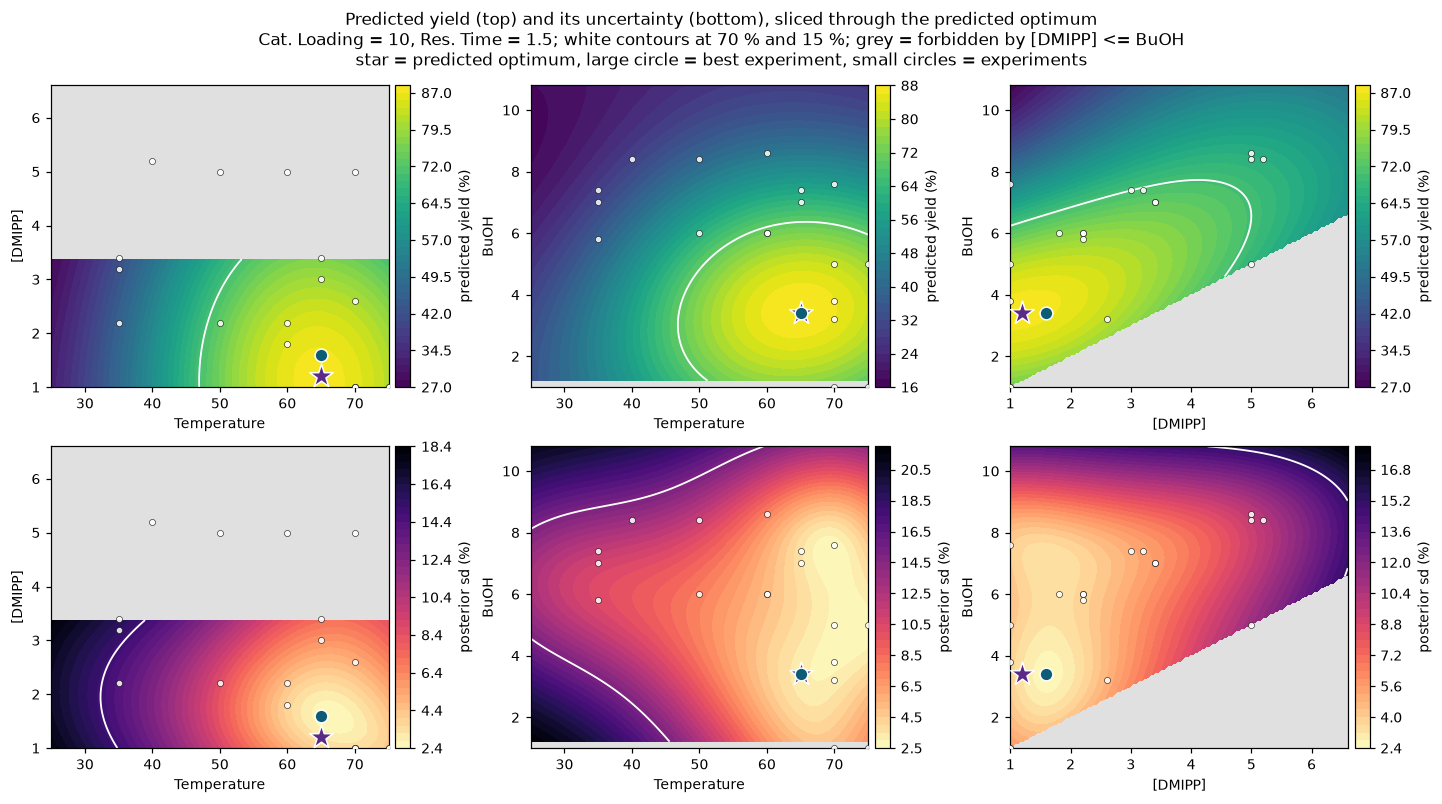

In [8]:
def slice_surface(strategy, x_key, y_key, background, n=140):
    xs = np.linspace(LEVELS[x_key].min(), LEVELS[x_key].max(), n)
    ys = np.linspace(LEVELS[y_key].min(), LEVELS[y_key].max(), n)
    XX, YY = np.meshgrid(xs, ys)
    scan = pd.DataFrame([background] * XX.size)
    scan[x_key], scan[y_key] = XX.ravel(), YY.ravel()
    mu, sd = predict(strategy, scan)
    outside = (scan["[DMIPP]"] > scan["BuOH"] + 1e-6).to_numpy()   # forbidden by the domain
    mu[outside] = np.nan
    sd[outside] = np.nan
    return xs, ys, mu.reshape(XX.shape), sd.reshape(XX.shape)


pairs = [("Temperature", "[DMIPP]"), ("Temperature", "BuOH"), ("[DMIPP]", "BuOH")]
background = optimum[PARAMETERS].to_dict()

fig, axes = plt.subplots(2, 3, figsize=(13, 7.2), constrained_layout=True)
for column, (x_key, y_key) in enumerate(pairs):
    xs, ys, mu, sd = slice_surface(strategy, x_key, y_key, background)
    for row, (field, cmap, label) in enumerate(
            [(mu, "viridis", "predicted yield (%)"), (sd, "magma_r", "posterior sd (%)")]):
        ax = axes[row, column]
        mesh = ax.contourf(xs, ys, field, levels=40, cmap=cmap)
        if row == 0:
            ax.contour(xs, ys, field, levels=[YIELD_THRESHOLD], colors="white", linewidths=1.2)
        else:
            ax.contour(xs, ys, field, levels=[SIGMA_MAX], colors="white", linewidths=1.2)
        ax.scatter(optimum[x_key], optimum[y_key], marker="*", s=260,
                   c="#5b2a86", edgecolors="white", linewidths=1.0, zorder=6)
        ax.scatter(best_experiment[x_key], best_experiment[y_key], marker="o", s=70,
                   c="#0d5c75", edgecolors="white", linewidths=1.0, zorder=6)
        ax.scatter(EXPERIMENTS[x_key], EXPERIMENTS[y_key], marker="o", s=16,
                   c="white", edgecolors="black", linewidths=0.4, alpha=0.85, zorder=5)
        ax.set_facecolor("0.88")          # blank = forbidden by [DMIPP] <= BuOH
        ax.set_xlabel(x_key); ax.set_ylabel(y_key)
        fig.colorbar(mesh, ax=ax, label=label, fraction=0.046, pad=0.02)

fig.suptitle("Predicted yield (top) and its uncertainty (bottom), sliced through the "
             f"predicted optimum\nCat. Loading = {optimum['Cat. Loading']:g}, "
             f"Res. Time = {optimum['Res. Time']:g}; white contours at "
             f"{YIELD_THRESHOLD:g} % and {SIGMA_MAX:g} %; grey = forbidden by "
             "[DMIPP] <= BuOH\nstar = predicted optimum, large circle = best "
             "experiment, small circles = experiments")
fig.savefig("figures/predicted_surface.png", dpi=200, bbox_inches="tight")
plt.show()

### The shape of the favourable region

Is the favourable region one body, or several disconnected islands? The question
matters: a single body can be walked through continuously, whereas islands would
mean distinct operating regimes.

It is tempting to answer by projecting the region onto its first two principal
components and looking. That figure is drawn below, and it is a good example of
why looking is not enough — it shows clean parallel bands, which read as
separate clusters and are nothing of the sort. Colouring the same projection by
temperature (right panel) identifies them immediately: one band per temperature
level. They are the grid, not the chemistry.

The question is therefore answered by counting instead of by eye. Two favourable
conditions are called adjacent when they differ by one increment in exactly one
parameter, and the connected components of the resulting graph are counted. A
single component means the region is one body in the only sense available on a
discrete domain: reachable by single steps without ever leaving it.

5,466 favourable conditions form 1 connected component(s)


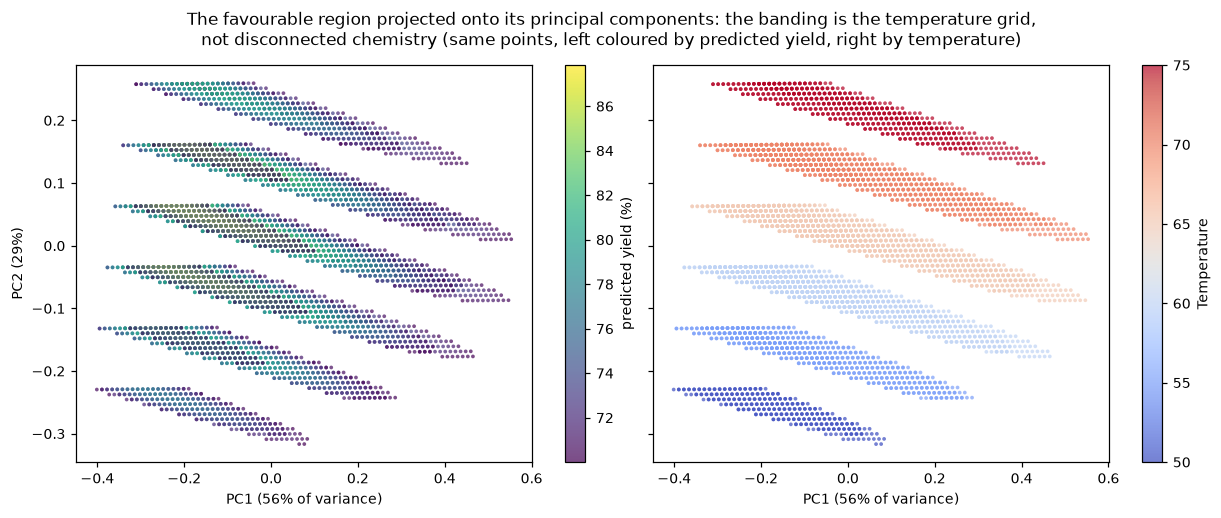

,[DMIPP],BuOH,Temperature
PC1,0.80,0.58,0.18
PC2,-0.22,0.00,0.97


In [9]:
def count_components(subset):
    # Connected components under single-increment moves along one parameter.
    position = {k: {v: i for i, v in enumerate(LEVELS[k])} for k in PARAMETERS}
    nodes = {tuple(position[k][v] for k, v in zip(PARAMETERS, row))
             for row in subset[PARAMETERS].itertuples(index=False)}
    seen, components = set(), 0
    for start in nodes:
        if start in seen:
            continue
        components += 1
        stack = [start]
        seen.add(start)
        while stack:
            node = stack.pop()
            for axis in range(len(PARAMETERS)):
                for move in (-1, 1):
                    neighbour = node[:axis] + (node[axis] + move,) + node[axis + 1:]
                    if neighbour in nodes and neighbour not in seen:
                        seen.add(neighbour)
                        stack.append(neighbour)
    return components


print(f"{len(favourable):,} favourable conditions form "
      f"{count_components(favourable)} connected component(s)")

axes_of_interest = ["[DMIPP]", "BuOH", "Temperature"]
scaled = np.column_stack([
    (favourable[k].to_numpy() - LEVELS[k].min()) / (LEVELS[k].max() - LEVELS[k].min())
    for k in axes_of_interest])
pca = PCA(2).fit(scaled)
embedding = pca.transform(scaled)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True, sharey=True)
for ax, (colour, cmap, label) in zip(axs, [
        (favourable.mu, "viridis", "predicted yield (%)"),
        (favourable["Temperature"], "coolwarm", "Temperature")]):
    points = ax.scatter(embedding[:, 0], embedding[:, 1], s=6, c=colour,
                        cmap=cmap, alpha=0.7, linewidths=0)
    fig.colorbar(points, ax=ax, label=label, fraction=0.046)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
axs[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
fig.suptitle("The favourable region projected onto its principal components: the "
             "banding is the temperature grid,\nnot disconnected chemistry "
             "(same points, left coloured by predicted yield, right by temperature)")
fig.savefig("figures/favourable_region_pca.png", dpi=200, bbox_inches="tight")
plt.show()

pd.DataFrame(pca.components_, columns=axes_of_interest,
             index=["PC1", "PC2"]).round(2)

## 7. A confirmatory experiment plan

The map is finally used to answer the questions a chemist asks once a campaign
is over, each of which restricts the reaction space in a different way: can the
catalyst loading be halved? does a high substrate concentration still work? can
the residence time be cut? For each, the best predicted yield within that
restriction is taken, subject to σ < 15 %.

Note what is and is not required. A scenario returns the best predicted yield it
can find while staying below the uncertainty cap; it is *not* required to clear
the 70 % favourable threshold. A row predicting a low yield with a small σ is
therefore a result in its own right — the model asserting that the restriction
costs yield — and is as useful to a process chemist as a row predicting a high
one.

Had no point in a region satisfied σ < 15 %, the scenario would have returned
nothing and the row would report the best point with the cap lifted, so that the
reader can see the size of the uncertainty being refused. That is a real outcome
of the procedure; it happens not to arise here, though one row sits close enough
to the cap to be read as marginal.

In [10]:
columns = {k: MAP[k].to_numpy() for k in PARAMETERS}
SCENARIOS = {
    "reference (global optimum)":        np.ones(len(MAP), bool),
    "Cat. Loading = 5":                  columns["Cat. Loading"] == 5.0,
    "Cat. Loading = 7.5":                columns["Cat. Loading"] == 7.5,
    "[DMIPP] >= 5.5 (high)":             columns["[DMIPP]"] >= 5.5,
    "[DMIPP] 4.0-5.4 (intermediate)":   (columns["[DMIPP]"] >= 4.0) & (columns["[DMIPP]"] < 5.5),
    "Res. Time <= 1 (short)":            np.isin(columns["Res. Time"], [0.5, 1.0]),
    "combined (Cat <= 7.5, [DMIPP] >= 4, Res. Time <= 1)":
        (columns["Cat. Loading"] <= 7.5) & (columns["[DMIPP]"] >= 4.0)
        & np.isin(columns["Res. Time"], [0.5, 1.0]),
}


def select(mask):
    # Best predicted yield in the region, subject to the uncertainty cap.
    confident = mask & (MAP.sd.to_numpy() < SIGMA_MAX)
    if confident.any():
        return MAP.iloc[int(np.argmax(np.where(confident, MAP.mu, -np.inf)))], True
    return MAP.iloc[int(np.argmax(np.where(mask, MAP.mu, -np.inf)))], False


plan = pd.DataFrame([
    {"scenario": name,
     **{k: point[k] for k in PARAMETERS},
     "predicted yield": round(point.mu, 1),
     "sd": round(point.sd, 1),
     "retained": "yes" if kept else f"no (sd = {point.sd:.0f} %)"}
    for name, (point, kept) in ((n, select(m)) for n, m in SCENARIOS.items())
])
plan

,scenario,[DMIPP],BuOH,Cat. Loading,Temperature,Res. Time,predicted yield,sd,retained
0,reference (global optimum),1.2,3.4,10.0,65.0,1.5,87.8,3.2,yes
1,Cat. Loading = 5,1.0,3.6,5.0,65.0,2.0,49.3,14.8,yes
2,Cat. Loading = 7.5,1.0,3.2,7.5,65.0,2.0,76.3,9.3,yes
3,[DMIPP] >= 5.5 (high),5.6,7.2,10.0,65.0,1.5,66.3,11.3,yes
4,[DMIPP] 4.0-5.4 (intermediate),4.0,5.4,10.0,65.0,1.5,76.1,8.0,yes
5,Res. Time <= 1 (short),1.4,4.0,10.0,65.0,1.0,76.1,6.1,yes
6,"combined (Cat <= 7.5, [DMIPP] >= 4, Res. Time ...",4.0,6.4,7.5,70.0,1.0,54.8,10.8,yes


## 8. The experiments that follow

Running this set tests the surrogate where it is most confident, which is also
where it is least likely to be surprising: this is the confirmatory half of the
work, not a continuation of the search. The rows whose predicted yield is low
are the informative ones — they are where the model commits to a restriction
being costly, and where a measurement either confirms the map or exposes it.

In [11]:
retained = plan[plan.retained == "yes"]
plan.to_csv("experiment_plan.csv", index=False)
retained.to_csv("experiment_plan_retained.csv", index=False)
print(f"{len(retained)} of {len(SCENARIOS)} scenarios returned an experiment "
      f"(sd < {SIGMA_MAX:g} %)")
retained[["scenario"] + PARAMETERS + ["predicted yield", "sd"]]

7 of 7 scenarios returned an experiment (sd < 15 %)


,scenario,[DMIPP],BuOH,Cat. Loading,Temperature,Res. Time,predicted yield,sd
0,reference (global optimum),1.2,3.4,10.0,65.0,1.5,87.8,3.2
1,Cat. Loading = 5,1.0,3.6,5.0,65.0,2.0,49.3,14.8
2,Cat. Loading = 7.5,1.0,3.2,7.5,65.0,2.0,76.3,9.3
3,[DMIPP] >= 5.5 (high),5.6,7.2,10.0,65.0,1.5,66.3,11.3
4,[DMIPP] 4.0-5.4 (intermediate),4.0,5.4,10.0,65.0,1.5,76.1,8.0
5,Res. Time <= 1 (short),1.4,4.0,10.0,65.0,1.0,76.1,6.1
6,"combined (Cat <= 7.5, [DMIPP] >= 4, Res. Time ...",4.0,6.4,7.5,70.0,1.0,54.8,10.8


## Notes

**Notation.** `[DMIPP]` and `BuOH` are both concentrations in mol L⁻¹ — the
constraint `[DMIPP] ≤ BuOH` compares them directly and would be meaningless
otherwise — so the second is written **[BuOH]** everywhere outside the code,
where it keeps the key under which the campaign recorded it. Concentrations are
quoted in M throughout, catalyst loading in mol%, temperature in °C and
residence time in min.

**σ is a property of the model, not of the chemistry.** The posterior standard
deviation says how far the surrogate's prediction might be from what the
surrogate itself would predict with more data of the same kind. It is calibrated
only to the extent that the fitted noise term reflects the true experimental
reproducibility, which 19 experiments cannot establish. The 15 % cap should be
read as "the campaign passed close enough to here", not as a confidence interval
on a measurement.

**The map is an interpolation, and where it is not, it says so.** Nineteen
experiments in five dimensions is sparse. What keeps the exercise honest is that
the same model reports both the prediction and its uncertainty, and that the
uncertainty cap is applied before any point is selected rather than after.

**The campaign shaped what can be said.** All nine proposals were made at 10
mol% catalyst, so that is where the surrogate is informed and where its
confidence is highest. The scenarios at 5 and 7.5 mol% are therefore asking the
model to speak about a part of the space the optimiser left behind early — which
is exactly why they are asked, and why some of them return nothing.

**The surrogate is not bounded by chemistry.** A Gaussian process on a
standardised yield knows nothing about 0 and 100 %, and predicts slightly
negative yields in the coldest, most dilute corner of the space, far from any
experiment. Nothing below depends on that corner, but it is a reminder that the
map is a smooth interpolation of 19 numbers and not a kinetic model.

**Arg-max of μ is not the next experiment of a campaign.** Selecting the highest
predicted yield is the right move for confirmation and the wrong one for
learning; an acquisition function would have chosen differently, and did, during
the campaign itself. The two are complementary and should not be swapped.

**Thresholds.** 70 % and 15 % were fixed before the plan was drawn and applied
uniformly. They are reported with the plan so that their effect is visible: a
lower uncertainty cap shrinks the plan and a higher one fills it with
extrapolation.

## References

1. Rasmussen, C. E.; Williams, C. K. I. *Gaussian Processes for Machine
   Learning.* MIT Press, **2006**. — ARD length scales, posterior variance
2. Balandat, M. *et al.* *BoTorch: A Framework for Efficient Monte-Carlo
   Bayesian Optimization.* NeurIPS **2020**.
3. Durholt, J. P. *et al.* *BoFire: Bayesian Optimization Framework Intended
   for Real Experiments.* **2024**, arXiv:2408.05040.
4. Shields, B. J. *et al.* *Bayesian reaction optimization as a tool for
   chemical synthesis.* *Nature* **2021**, *590*, 89–96.